In [9]:
import numpy as np

# frequência de amostragem
fs = 1000

# vetor do tempo
tempo = np.arange(0, 1, 1/fs)

# sinal com componente senoidal + ruído
sinal = np.sin(2*np.pi*50*tempo) + 0.2*np.random.randn(len(tempo))

# cálculo do valor RMS
rms = np.sqrt(np.mean(sinal**2))

print("Valor RMS:", rms)


Valor RMS: 0.7310836599476275


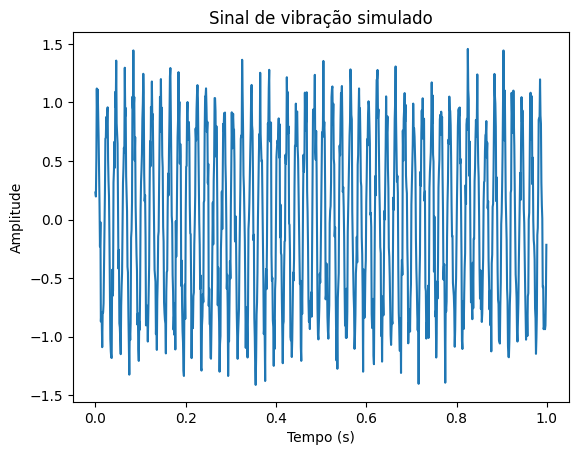

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# plotagem
plt.plot(tempo, sinal)
plt.title("Sinal de vibração simulado")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.show()


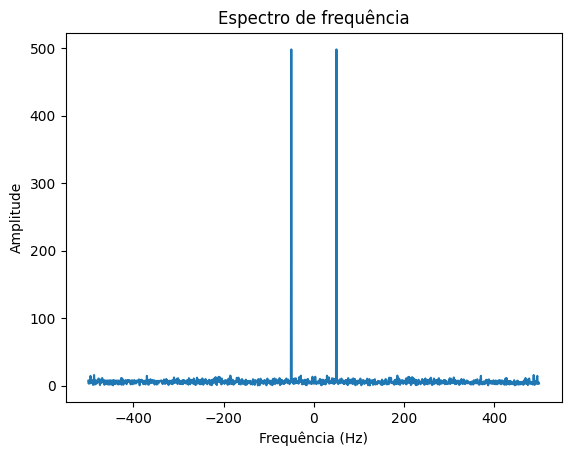

In [11]:
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

fft_vals = fft(sinal)
freq = fftfreq(len(sinal), 1/fs)

plt.plot(freq, np.abs(fft_vals))
plt.title("Espectro de frequência")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
from scipy.stats import kurtosis
# cálculo dos atributos

# média
media = np.mean(sinal)
# desvio padrão
desvio_padrao = np.std(sinal)
# valor máximo absoluto (Peak)
valor_maximo = np.max(np.abs(sinal))
# RMS (Root Mean Square)
rms = np.sqrt(np.mean(sinal**2))
# fator de crista (Crest Factor)
fator_crista = valor_maximo / rms
# curtose (Kurtosis)
curtose = kurtosis(sinal, fisher=False)
# exibição dos resultados
print("Atributos extraídos do sinal de vibração:")
print(f"Média: {media:.4f}")
print(f"Desvio padrão: {desvio_padrao:.4f}")
print(f"Valor máximo (Peak): {valor_maximo:.4f}")
print(f"RMS: {rms:.4f}")
print(f"Fator de crista: {fator_crista:.4f}")
print(f"Curtose: {curtose:.4f}")

Atributos extraídos do sinal de vibração:
Média: -0.0030
Desvio padrão: 0.7311
Valor máximo (Peak): 1.4569
RMS: 0.7311
Fator de crista: 1.9928
Curtose: 1.7057


In [13]:
janela = 100
atributos = []

for i in range(0, len(sinal)-janela, janela):

    trecho = sinal[i:i+janela]

    rms = np.sqrt(np.mean(trecho**2))
    peak = np.max(np.abs(trecho))
    crest = peak / rms
    kurt = kurtosis(trecho, fisher=False)

    atributos.append([rms, peak, crest, kurt])

atributos = np.array(atributos)

print("Shape da matriz de atributos:", atributos.shape)


Shape da matriz de atributos: (9, 4)


In [17]:
import pandas as pd
df_atributos = pd.DataFrame(atributos, columns=["RMS", "Peak", "Crest", "Kurtosis"])
df_atributos


,RMS,Peak,Crest,Kurtosis
0,0.760045,1.444092,1.900008,1.714455
1,0.738972,1.335479,1.807213,1.711486
2,0.743084,1.335566,1.797328,1.667907
3,0.757155,1.411961,1.864823,1.724517
4,0.713360,1.235687,1.732207,1.623221
5,0.728481,1.354200,1.858936,1.724948
6,0.746061,1.309742,1.755544,1.676314
7,0.706091,1.402603,1.986435,1.640792
8,0.683595,1.456920,2.131263,1.766544


In [20]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Gerando base sintética com MAIS OVERLAP para acurácia ~85-92%
np.random.seed(42)
n_normal = 200
n_falha = 100

# Normal: RMS baixo-médio, kurtosis ~2.8-3.5, crest 1.1-2.0 (overlap forte)
rms_normal = np.random.normal(0.045, 0.015, n_normal)  # Média maior
kurt_normal = np.random.normal(3.0, 0.6, n_normal)
crest_normal = np.random.normal(1.6, 0.4, n_normal)

# Falha: RMS médio, kurtosis 3.5-6.5, crest 2.5-5.5 (overlap)
rms_falha = np.random.normal(0.18, 0.08, n_falha)      # Média menor, std alta
kurt_falha = np.random.normal(4.8, 1.2, n_falha)
crest_falha = np.random.normal(3.8, 1.2, n_falha)

# Ruído adicional e outliers aleatórios
noise_scale = 0.03
noise_rms = np.random.normal(0, noise_scale, n_normal + n_falha)
noise_kurt = np.random.normal(0, 0.4, n_normal + n_falha)
noise_crest = np.random.normal(0, 0.3, n_normal + n_falha)

X_normal = np.column_stack([
    np.clip(rms_normal + noise_rms[:n_normal], 0.01, None),
    np.clip(kurt_normal + noise_kurt[:n_normal], 1.5, None),
    np.clip(crest_normal + noise_crest[:n_normal], 1.0, None)
])
X_falha = np.column_stack([
    np.clip(rms_falha + noise_rms[n_normal:], 0.01, None),
    np.clip(kurt_falha + noise_kurt[n_normal:], 2.5, None),
    np.clip(crest_falha + noise_crest[n_normal:], 1.5, None)
])
X = np.vstack([X_normal, X_falha])

# Injetando 10% de mislabels para realismo (ruído de rótulo)
y_base = np.array([0] * n_normal + [1] * n_falha)
mislabel_indices = np.random.choice(len(y_base), size=int(0.1 * len(y_base)), replace=False)
y = y_base.copy()
y[mislabel_indices] = 1 - y[mislabel_indices]  # Flip labels



In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
# Divisão treino/teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
# Treinamento e avaliação
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)
acuracia = accuracy_score(y_teste, previsoes)

importancias = pd.DataFrame({
    'Feature': ['RMS', 'Kurtosis', 'Crest Factor'],
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=False)

print("Acurácia:", acuracia)
print("\nPrevisões (primeiros 10):", previsoes[:10])
print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes))
print("\nImportância das Features:")
print(importancias)


Acurácia: 0.88

Previsões (primeiros 10): [1 0 0 0 0 1 0 0 0 1]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91        49
           1       0.79      0.88      0.84        26

    accuracy                           0.88        75
   macro avg       0.86      0.88      0.87        75
weighted avg       0.89      0.88      0.88        75


Importância das Features:
        Feature  Importancia
0           RMS     0.378496
2  Crest Factor     0.339182
1      Kurtosis     0.282322
